In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier


In [2]:
df=pd.read_csv("C:/Users/Moavia Computer/OneDrive/Desktop/diabetes.csv")

In [58]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [59]:
df.Outcome.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [60]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
X=df.drop('Outcome',axis=1
          )
y=df['Outcome']



y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [63]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2)
x_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
599,1,109,38,18,120,23.1,0.407,26
407,0,101,62,0,0,21.9,0.336,25
442,4,117,64,27,120,33.2,0.230,24
523,9,130,70,0,0,34.2,0.652,45
209,7,184,84,33,0,35.5,0.355,41
...,...,...,...,...,...,...,...,...
0,6,148,72,35,0,33.6,0.627,50
741,3,102,44,20,94,30.8,0.400,26
345,8,126,88,36,108,38.5,0.349,49
476,2,105,80,45,191,33.7,0.711,29


In [64]:
clf=DecisionTreeClassifier(max_depth=5)
clf.fit(x_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [65]:
y_pred=clf.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0])

In [66]:
from sklearn.metrics import accuracy_score,confusion_matrix,auc,roc_curve

In [67]:
accuracy_score(y_test,y_pred)

0.7792207792207793

In [68]:
cnf=confusion_matrix(y_test,y_pred)

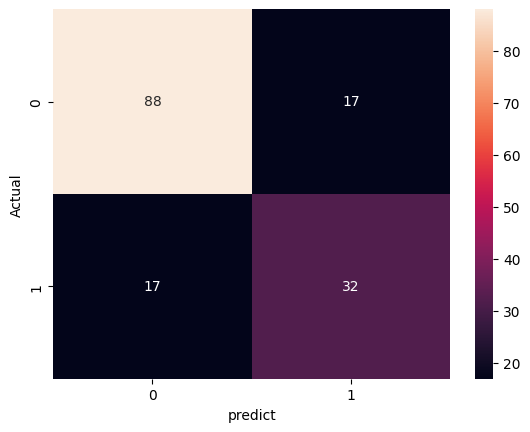

In [69]:
plt.Figure(figsize=(10,5))
sns.heatmap(cnf,annot=True)
plt.xlabel('predict')
plt.ylabel("Actual")
plt.show()

In [70]:
from sklearn.metrics import roc_auc_score

In [71]:
y_prob=clf.predict_proba(x_test)[:,1]# just to catch probabliity
fpr,tpr,threshold=roc_curve(y_test,y_prob)
auc_score=roc_auc_score(y_test,y_prob)


In [72]:
auc_score

0.8058309037900875

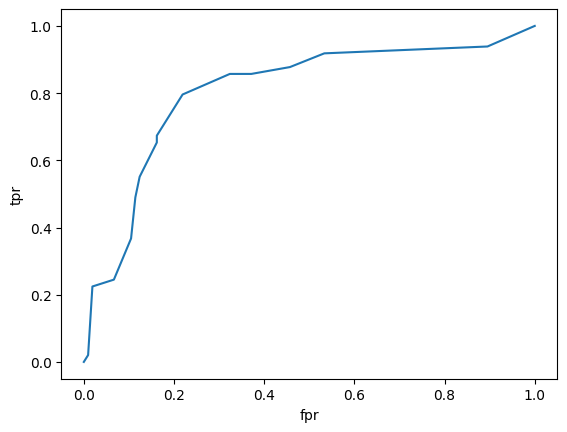

In [73]:
plt.plot(fpr,tpr,label=f'AUC={auc_score:.3f}')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.show()

In [74]:
X.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [75]:
feature_cols=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']

[Text(0.47836538461538464, 0.9166666666666666, 'Glucose <= 128.5\ngini = 0.459\nsamples = 614\nvalue = [395.0, 219.0]\nclass = 0'),
 Text(0.23557692307692307, 0.75, 'Age <= 28.5\ngini = 0.323\nsamples = 390\nvalue = [311, 79]\nclass = 0'),
 Text(0.35697115384615385, 0.8333333333333333, 'True  '),
 Text(0.125, 0.5833333333333334, 'BMI <= 45.4\ngini = 0.177\nsamples = 214\nvalue = [193, 21]\nclass = 0'),
 Text(0.07692307692307693, 0.4166666666666667, 'BMI <= 30.95\ngini = 0.157\nsamples = 210\nvalue = [192, 18]\nclass = 0'),
 Text(0.038461538461538464, 0.25, 'Pregnancies <= 7.5\ngini = 0.034\nsamples = 114\nvalue = [112, 2]\nclass = 0'),
 Text(0.019230769230769232, 0.08333333333333333, 'gini = 0.018\nsamples = 113\nvalue = [112, 1]\nclass = 0'),
 Text(0.057692307692307696, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = 1'),
 Text(0.11538461538461539, 0.25, 'DiabetesPedigreeFunction <= 0.509\ngini = 0.278\nsamples = 96\nvalue = [80, 16]\nclass = 0'),
 Text(0.096153

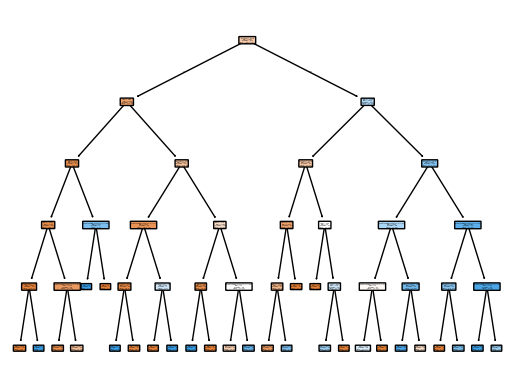

In [76]:
from sklearn.tree import plot_tree
plot_tree(clf,feature_names=feature_cols,class_names=[str(i) for i in clf.classes_],filled=True,rounded=True)
